In [1]:
import numpy as np
from pytdigest import TDigest        # explicit package
# check details here: https://raw.githubusercontent.com/protivinsky/pytdigest/main/pytdigest/pytdigest.py

def create_digest(data, weights=None, compression=300):
    """Create a t-digest object for given data and compression parameter"""
    data = np.asarray(data)
    #if weights is None:
    #    weights = np.ones_like(data)
    td = TDigest.compute(data, weights, compression=compression)  # vectorised C loop
    return td

def get_quantiles_from_tdigest(td,
                               quantile_list=
                                  ( [.0000001, .000001, .00001, .0001, .001, .01]
                                   + list(np.arange(.1, .95, .05))
                                   + [.99, .999, .9999, .99999, .999999, .9999999])
                               ):
    """Create quantiles from a given data->t-digest and specified quantile values."""
    #td = create_digest(data)
    #print(td)
    #td = digest
    quantiles = [td.inverse_cdf(q) for q in quantile_list]
    return  quantiles, quantile_list

if __name__ == "__main__":

    N = 10_000_000
    data = np.random.uniform(0, 100, N)

    td = create_digest(data)
    print(type(td))
   # print(end - start)

    #qs = [.0000001, .000001, .00001, .0001, .001, .01] \
    # + list(np.arange(.1, .95, .05)) \
    # + [.99, .999, .9999, .99999, .999999, .9999999]

    print(get_quantiles_from_tdigest(td))

    #digest_dict = td.to_dict()
    #print(digest_dict)

<class 'pytdigest.pytdigest.TDigest'>
([1.551465566018706e-05, 0.0001036696077664582, 0.0008644893306110646, 0.009577208815427474, 0.09968797958021847, 1.0004154920684725, 10.00889900040555, 14.998416677319751, 20.136605553407357, 25.297819926969122, 29.981975533068628, 34.84651930703767, 40.084549555852696, 45.21168690902865, 50.05788157683842, 54.802174368259216, 60.074515947991934, 65.01121740291586, 69.85362438887023, 74.79677481680908, 79.89907032698224, 85.02627893312504, 89.87638293691859, 98.99413994844957, 99.89876625490658, 99.9897845302339, 99.99898466400796, 99.99988674279584, 99.99999160890638], [1e-07, 1e-06, 1e-05, 0.0001, 0.001, 0.01, 0.1, 0.15000000000000002, 0.20000000000000004, 0.25000000000000006, 0.30000000000000004, 0.3500000000000001, 0.40000000000000013, 0.45000000000000007, 0.5000000000000001, 0.5500000000000002, 0.6000000000000002, 0.6500000000000001, 0.7000000000000002, 0.7500000000000002, 0.8000000000000002, 0.8500000000000002, 0.9000000000000002, 0.99, 0.99

In [5]:
N = 10_000_000

data_uniform = np.random.uniform(0, 0, N)   # N samples in [0, 100)
data_normal  = np.random.normal(0, 1, N)      # mean=0, std=1, N samples

In [6]:
td = create_digest(data_uniform)

quantile_values, quantile_list = get_quantiles_from_tdigest(td)


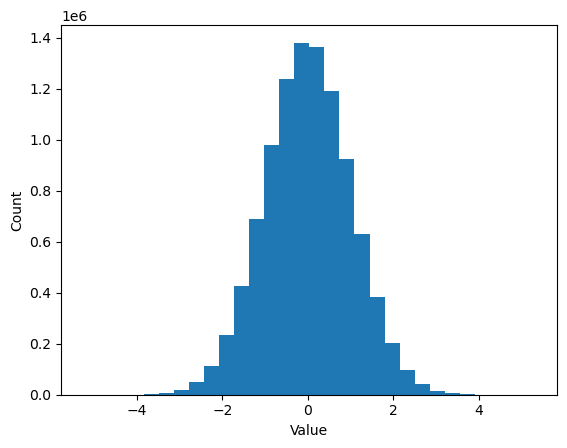

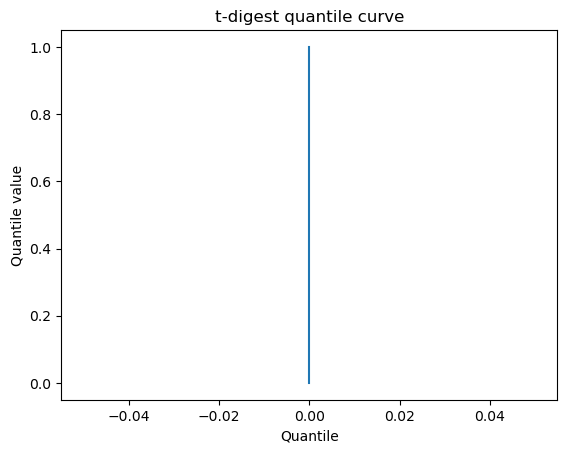

In [7]:
import matplotlib.pyplot as plt

# histogram of data_uniform
plt.figure()
plt.hist(data_normal, bins=30)
plt.xlabel("Value")
plt.ylabel("Count")
#plt.title("Histogram of data_uniform")
plt.show()

# quantile_values (y) vs quantile_list (x)
plt.figure()
plt.plot(quantile_values, quantile_list)
plt.xlabel("Quantile")
plt.ylabel("Quantile value")
plt.title("t-digest quantile curve")
plt.show()